<a href="https://colab.research.google.com/github/priyadarshinivr19/Minors-Degree-Machine-Learning/blob/main/CSMI17_Artificial_Intelligence_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Robot Path-finding Problem**

In [23]:
import math
import random
import time
from heapq import heappush, heappop
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Configurations**

This section defines the key parameters that control the experimental setup for the A* pathfinding benchmark. The TRIALS variable specifies how many random grid environments are generated and tested for each heuristic. GRID_SIZE determines the dimensions of each grid, while OBSTACLE_DENSITY controls how cluttered the environment is by setting the probability that a cell is blocked. To ensure reproducible results, a fixed RANDOM_SEED is used to initialize both Python’s and NumPy’s random number generators. Changing or removing the seed introduces full randomness in every run.

In [24]:
TRIALS = 100
GRID_SIZE = (30, 30)
OBSTACLE_DENSITY = 0.25
RANDOM_SEED = 42

if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

**Grid Generation**

In this section of the code, the grid environment and movement logic for the robot are defined. The grid is represented as a binary matrix, where each cell can either be free (0) or blocked (1). The constants FREE, BLOCK = 0, 1 are used to make the code more readable and meaningful. The function make_grid(rows, cols, obstacle_density) creates a random grid of specified size, where obstacles are placed based on a given probability. It initializes a matrix of zeros (free cells) and randomly marks some of them as blocked using a mask generated from NumPy’s random number generator. The function random_free_cell(grid) then selects a random free cell — one that is not blocked — to serve as the robot’s start or goal position. Finally, the neighbors(grid, r, c) function defines the robot’s movement model. Since diagonal moves are not allowed, it only considers the four primary directions — up, down, left, and right — represented by the coordinate offsets (-1,0), (1,0), (0,-1), and (0,1). For each valid neighboring cell that lies within the grid and is free of obstacles, the function yields that cell along with a movement cost of 1.0, indicating that all orthogonal moves have equal cost.

In [25]:
FREE, BLOCK = 0, 1

def make_grid(rows, cols, obstacle_density):
    grid = np.zeros((rows, cols), dtype=np.uint8)
    mask = np.random.rand(rows, cols) < obstacle_density
    grid[mask] = BLOCK
    return grid


In [26]:
def random_free_cell(grid):
    rows, cols = grid.shape
    while True:
        r, c = random.randrange(rows), random.randrange(cols)
        if grid[r, c] == FREE:
            return (r, c)

In [27]:
def neighbors(grid, r, c):
    rows, cols = grid.shape
    steps_4 = [(-1,0), (1,0), (0,-1), (0,1)]
    for dr, dc in steps_4:
        nr, nc = r + dr, c + dc
        if 0 <= nr < rows and 0 <= nc < cols and grid[nr, nc] == FREE:
            yield (nr, nc), 1.0

**Heuristics**

This section defines the three heuristic functions used by the A* algorithm to estimate the remaining cost from any node to the goal. The Manhattan distance computes the sum of the absolute horizontal and vertical differences between two points and is the most appropriate heuristic for 4-connected grids, where movement is restricted to up, down, left, and right. The Euclidean distance measures the straight-line (“as the crow flies”) distance between two points, which is always less than or equal to the Manhattan distance, making it admissible but generally less informed in this context. The Chebyshev distance takes the maximum of the horizontal and vertical differences, effectively representing the number of king moves required on a chessboard; it is also admissible in 4-connected motion but provides a weaker estimate. The get_heuristics() function simply groups these three heuristic functions into a dictionary for easy iteration and performance comparison during the experiment.

In [28]:
def manhattan(a, b):
    (r1, c1), (r2, c2) = a, b
    return abs(r1 - r2) + abs(c1 - c2)

def euclidean(a, b):
    (r1, c1), (r2, c2) = a, b
    return math.hypot(r1 - r2, c1 - c2)

def chebyshev(a, b):
    (r1, c1), (r2, c2) = a, b
    return max(abs(r1 - r2), abs(c1 - c2))

def get_heuristics(diagonals=True):

    return {
        "Manhattan": manhattan,
        "Euclidean": euclidean,
        "Chebyshev": chebyshev
    }


**A - Star Search**

This function implements the **A\*** search algorithm, which is used to find the shortest and most efficient path from a start cell to a goal cell in the grid. It works by combining both the actual cost so far (`g`) and an estimated cost to reach the goal (`h`) using the formula:

\[
f(n) = g(n) + h(n)
\]

A priority queue (`open_heap`) is used to always expand the node with the smallest total estimated cost `f(n)`. The algorithm maintains three main mappings:
- `g`: stores the actual path cost from the start node.
- `f`: stores the estimated total cost (`g + h`).
- `parent`: keeps track of each node’s predecessor for reconstructing the path.

During execution, nodes are expanded in increasing order of `f(n)` until the goal is reached. When the goal is found, the algorithm traces back through the `parent` links to reconstruct the final path. If no valid route exists, it returns failure with an infinite path cost. The number of expanded nodes (`nodes_expanded`) is also recorded to evaluate the efficiency of different heuristics.

In [29]:
def astar(grid, start, goal, h_func):

    open_heap = []
    g = {start: 0.0}
    f = {start: h_func(start, goal)}
    parent = {start: None}
    heappush(open_heap, (f[start], 0.0, start))
    closed = set()
    nodes_expanded = 0

    while open_heap:
        _, g_curr, current = heappop(open_heap)
        if current in closed:
            continue
        closed.add(current)
        nodes_expanded += 1

        if current == goal:
            path = []
            cur = current
            while cur is not None:
                path.append(cur)
                cur = parent[cur]
            path.reverse()
            return {
                "found": True,
                "path": path,
                "path_cost": g[current],
                "nodes_expanded": nodes_expanded
            }

        r, c = current
        for (nbr, step_cost) in neighbors(grid, r, c):
            tentative_g = g[current] + step_cost
            if nbr in closed and tentative_g >= g.get(nbr, float("inf")):
                continue
            if tentative_g < g.get(nbr, float("inf")):
                g[nbr] = tentative_g
                parent[nbr] = current
                f[nbr] = tentative_g + h_func(nbr, goal)
                heappush(open_heap, (f[nbr], tentative_g, nbr))

    return {
        "found": False,
        "path": None,
        "path_cost": float("inf"),
        "nodes_expanded": nodes_expanded
    }

**Trials**

This part of the code handles the benchmarking and performance evaluation of the A* algorithm across different heuristics. The run_trials() function runs multiple experiments (trials) on randomly generated grids of a specified size and obstacle density. For each trial, it randomly selects a start and goal cell, ensuring they are distinct and not blocked, and then runs the A* algorithm using all three heuristics—Manhattan, Euclidean, and Chebyshev. For every run, it records key performance metrics such as whether a path was found, the path length and cost, the number of nodes expanded, and the runtime in milliseconds. All results are stored in a pandas DataFrame for easy analysis. The summarize() function then aggregates these results by heuristic, computing summary statistics like success rate, average nodes expanded, average path cost, and average runtime. The output provides a concise comparison of how each heuristic performs in terms of accuracy, efficiency, and computational cost.

In [30]:
def run_trials(trials, grid_size, obstacle_density):
    rows, cols = grid_size
    heuristics = get_heuristics()
    results = []

    for t in range(trials):
        grid = make_grid(rows, cols, obstacle_density)
        if np.all(grid == BLOCK):
            grid = np.zeros_like(grid)

        start = random_free_cell(grid)
        goal = random_free_cell(grid)
        tries = 0
        while goal == start and tries < 10:
            goal = random_free_cell(grid)
            tries += 1

        grid[start] = FREE
        grid[goal] = FREE

        for hname, hfunc in heuristics.items():
            t0 = time.perf_counter()
            outcome = astar(grid, start, goal, hfunc)
            dt = (time.perf_counter() - t0) * 1000.0  # runtime in ms

            results.append({
                "trial": t + 1,
                "heuristic": hname,
                "found": outcome["found"],
                "path_length": len(outcome["path"]) if outcome["found"] else 0,
                "path_cost": outcome["path_cost"],
                "nodes_expanded": outcome["nodes_expanded"],
                "runtime_ms": dt,
                "rows": rows,
                "cols": cols,
                "obstacle_density": obstacle_density,
                "start": start,
                "goal": goal
            })
    return pd.DataFrame(results)



In [31]:
def summarize(df):
    summary = []
    for hname, g in df.groupby("heuristic"):
        attempts = len(g)
        succ = g["found"].sum()
        succ_rate = succ / attempts * 100.0
        avg_nodes = g.loc[g["found"], "nodes_expanded"].mean() if succ > 0 else float("nan")
        avg_cost  = g.loc[g["found"], "path_cost"].mean()     if succ > 0 else float("nan")
        avg_len   = g.loc[g["found"], "path_length"].mean()   if succ > 0 else float("nan")
        avg_time  = g["runtime_ms"].mean()
        summary.append({
            "heuristic": hname,
            "trials": attempts,
            "successes": int(succ),
            "success_rate_%": succ_rate,
            "avg_nodes_expanded_on_success": avg_nodes,
            "avg_path_cost_on_success": avg_cost,
            "avg_path_length_on_success": avg_len,
            "avg_runtime_ms_all": avg_time
        })
    return pd.DataFrame(summary).sort_values("heuristic").reset_index(drop=True)

The `main()` function acts as the central controller for the entire A* pathfinding experiment. It orchestrates every step — running trials, summarizing results, saving data, and generating performance visualizations.

First, it calls **`run_trials()`**, which performs multiple A* searches on randomly generated grids using all three heuristics and records metrics such as path cost, runtime, and nodes expanded. The collected data is stored in a pandas DataFrame (`df`). Then, **`summarize()`** aggregates this raw data by heuristic, calculating averages for success rate, path cost, runtime, and efficiency metrics, returning a summary DataFrame (`summary_df`).

Both the detailed and summarized results are saved as CSV files (`astar_trials_raw.csv` and `astar_trials_summary.csv`) for later use. The summary table is also printed in the output for quick inspection.

Next, the function generates **bar charts** to visualize heuristic performance:
1. **Success Rate (%):** How often each heuristic successfully finds a path.  
2. **Average Nodes Expanded:** How efficiently the heuristic explores the grid.  
3. **Average Path Cost:** Indicates whether the paths found are optimal.  
4. **Average Runtime (ms):** Measures computational speed.

Each figure compares all heuristics side by side. Finally, `plt.show()` displays the plots, and the line `if __name__ == "__main__": main()` ensures that the experiment runs only when the script is executed directly. Together, this makes `main()` the orchestrator of the entire A* benchmark workflow.

Saved CSVs: astar_trials_raw.csv, astar_trials_summary.csv

heuristic  trials  successes  success_rate_%  avg_nodes_expanded_on_success  avg_path_cost_on_success  avg_path_length_on_success  avg_runtime_ms_all
Chebyshev     100         97            97.0                     156.164948                 23.701031                   24.701031            0.608713
Euclidean     100         97            97.0                     131.752577                 23.701031                   24.701031            0.474671
Manhattan     100         97            97.0                      92.463918                 23.701031                   24.701031            0.359037 



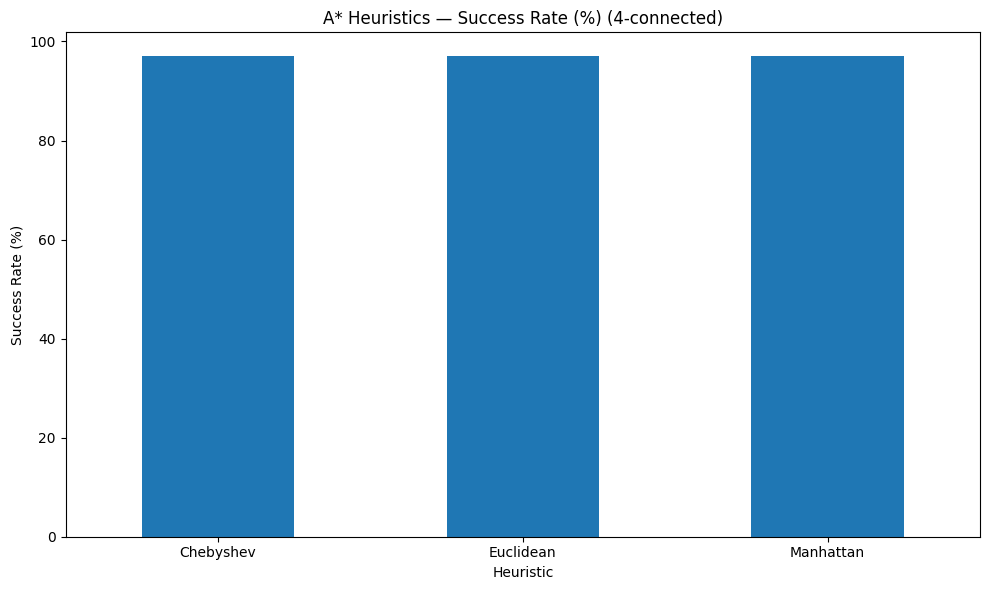

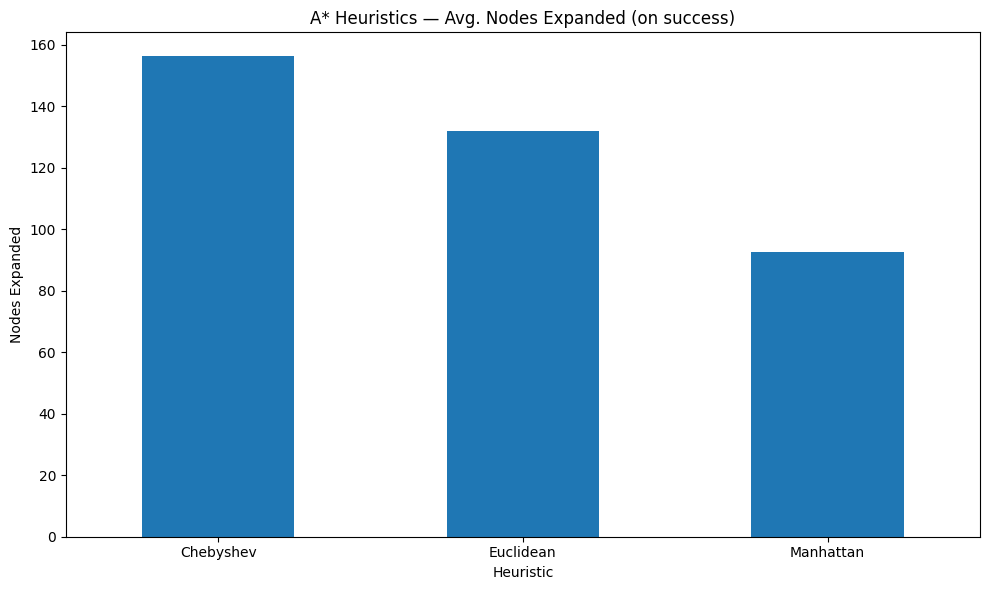

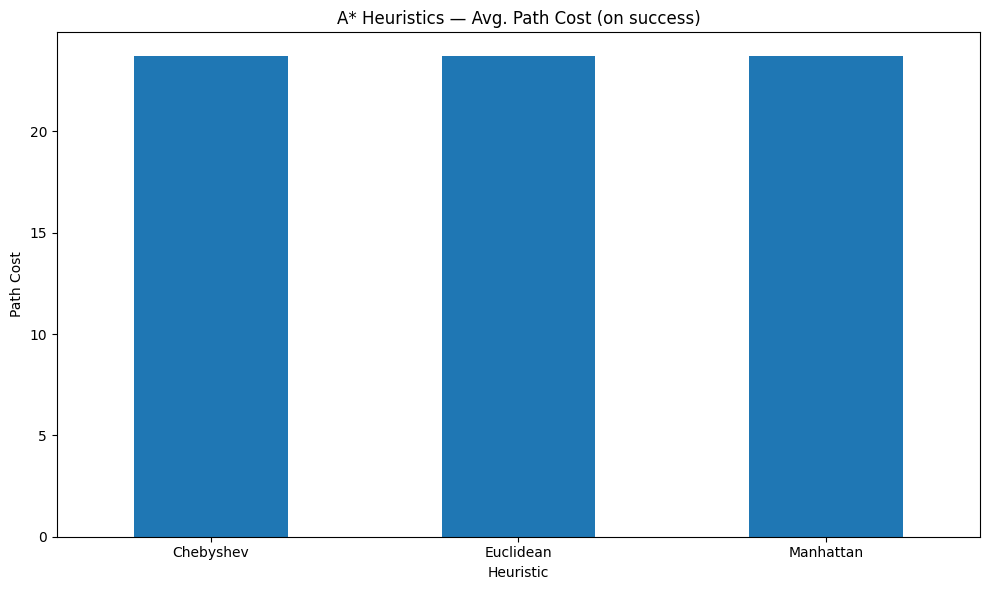

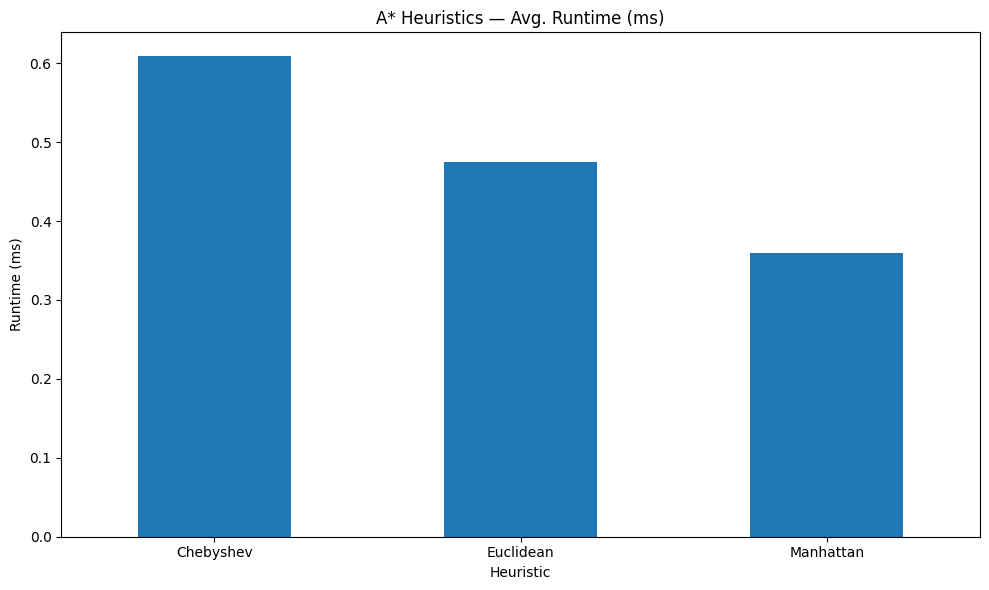

In [32]:
def main():
    df = run_trials(TRIALS, GRID_SIZE, OBSTACLE_DENSITY)
    summary_df = summarize(df)

    # Save data
    df.to_csv("astar_trials_raw.csv", index=False)
    summary_df.to_csv("astar_trials_summary.csv", index=False)
    print("Saved CSVs: astar_trials_raw.csv, astar_trials_summary.csv\n")
    print(summary_df.to_string(index=False), "\n")

    # Visualization
    plt.figure()
    summary_df.set_index("heuristic")["success_rate_%"].plot(kind="bar", rot=0)
    plt.title("A* Heuristics — Success Rate (%) (4-connected)")
    plt.ylabel("Success Rate (%)")
    plt.xlabel("Heuristic")
    plt.tight_layout()

    plt.figure()
    summary_df.set_index("heuristic")["avg_nodes_expanded_on_success"].plot(kind="bar", rot=0)
    plt.title("A* Heuristics — Avg. Nodes Expanded (on success)")
    plt.ylabel("Nodes Expanded")
    plt.xlabel("Heuristic")
    plt.tight_layout()

    plt.figure()
    summary_df.set_index("heuristic")["avg_path_cost_on_success"].plot(kind="bar", rot=0)
    plt.title("A* Heuristics — Avg. Path Cost (on success)")
    plt.ylabel("Path Cost")
    plt.xlabel("Heuristic")
    plt.tight_layout()

    plt.figure()
    summary_df.set_index("heuristic")["avg_runtime_ms_all"].plot(kind="bar", rot=0)
    plt.title("A* Heuristics — Avg. Runtime (ms)")
    plt.ylabel("Runtime (ms)")
    plt.xlabel("Heuristic")
    plt.tight_layout()

    plt.show()

if __name__ == "__main__":
    main()

**Visualization**

In [33]:
def draw_grid_and_path(grid, path=None, start=None, goal=None, figsize=(6, 6)):

    img = np.zeros((*grid.shape, 3), dtype=float)
    img[grid == 0] = [1.0, 1.0, 1.0]
    img[grid == 1] = [0.0, 0.0, 0.0]


    if path:
        for (r, c) in path:
            img[r, c] = [0.2, 0.6, 1.0]

    if start is not None:
        r, c = start
        img[r, c] = [0.2, 1.0, 0.2]
    if goal is not None:
        r, c = goal
        img[r, c] = [1.0, 0.2, 0.2]

    plt.figure(figsize=figsize)
    plt.imshow(img, interpolation="nearest")

    rows, cols = grid.shape
    plt.xticks(np.arange(-0.5, cols, 1), [])
    plt.yticks(np.arange(-0.5, rows, 1), [])
    plt.grid(color="gray", linestyle="-", linewidth=0.5)
    plt.title("A* Pathfinding Grid (green=start, red=goal, blue=path)")
    plt.axis("on")
    plt.gca().invert_yaxis()
    plt.show()

def run_one_example(heuristic_name="Manhattan", rows=20, cols=20, obstacle_density=0.25):

    np.random.seed(None)
    random.seed(None)

    grid = make_grid(rows, cols, obstacle_density)
    if np.all(grid == BLOCK):
        grid = np.zeros_like(grid)

    start = random_free_cell(grid)
    goal = random_free_cell(grid)
    tries = 0
    while goal == start and tries < 10:
        goal = random_free_cell(grid)
        tries += 1

    grid[start] = FREE
    grid[goal] = FREE

    heuristics = get_heuristics()
    if heuristic_name not in heuristics:
        raise ValueError(f"Heuristic '{heuristic_name}' not found. Choose from {list(heuristics.keys())}")
    h = heuristics[heuristic_name]

    result = astar(grid, start, goal, h)

    if result["found"]:
        print(f"[{heuristic_name}] Path found! Cost={result['path_cost']}, Nodes expanded={result['nodes_expanded']}")
        draw_grid_and_path(grid, result["path"], start=start, goal=goal)
    else:
        print(f"[{heuristic_name}] No path found.")
        draw_grid_and_path(grid, None, start=start, goal=goal)



[Manhattan] Path found! Cost=13.0, Nodes expanded=20


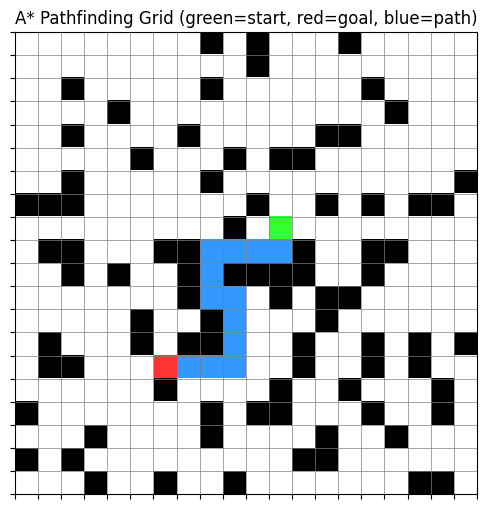

In [34]:
run_one_example("Manhattan")


#**Timetable Generation Problem**

The Timetable Generation Problem is a **Constraint Satisfaction Problem (CSP)** where each course must be assigned a valid **timeslot** and **room** such that all scheduling rules are satisfied. Each course is taught by a specific teacher and attended by a specific student group. The key constraints are:

(1) no teacher can teach two courses at the same time,

(2) no student group can attend two classes in the same timeslot, and

(3) no two courses can occupy the same room at the same time.

The objective is to find a feasible timetable that satisfies all these constraints simultaneously, ensuring there are no overlaps in teacher schedules, student schedules, or room usage.

In [35]:
import itertools
import random
import time
from dataclasses import dataclass
from typing import Dict, List, Optional, Set, Tuple
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams["figure.figsize"] = (10, 6)

**Defining Classes**

This section defines the **core data structures** used for the timetabling problem using Python `@dataclass`.

- **Course** represents a class with its assigned teacher, student group, and class size.  
- **Room** represents a classroom with a specific seating capacity.  
- **TimetableProblem** stores all courses, rooms, and the overall scheduling grid defined by number of days and slots per day.  

It also includes:  
1. A `timeslots` property that lists all possible time positions in the week.  
2. A `conflict_graph()` method that builds a **conflict network** showing which courses cannot occur at the same time (because they share the same teacher or student group).

In [36]:
@dataclass
class Course:
    id: int
    teacher: int
    group: int
    size: int

In [37]:
@dataclass
class Room:
    id: int

In [38]:
@dataclass
class TimetableProblem:
    courses: List[Course]
    rooms: List[Room]
    n_days: int
    slots_per_day: int

    @property
    def timeslots(self) -> List[int]:
        return list(range(self.n_days * self.slots_per_day))

    def conflict_graph(self) -> Dict[int, Set[int]]:
        neighbors: Dict[int, Set[int]] = {c.id: set() for c in self.courses}
        by_teacher: Dict[int, List[int]] = {}
        by_group: Dict[int, List[int]] = {}

        for c in self.courses:
            by_teacher.setdefault(c.teacher, []).append(c.id)
            by_group.setdefault(c.group, []).append(c.id)

        for bucket in by_teacher.values():
            for a, b in itertools.combinations(bucket, 2):
                neighbors[a].add(b)
                neighbors[b].add(a)

        for bucket in by_group.values():
            for a, b in itertools.combinations(bucket, 2):
                neighbors[a].add(b)
                neighbors[b].add(a)

        return neighbors

**Problem Generation**

This function, `make_random_problem()`, automatically **creates a random timetabling instance** for testing the algorithm. It takes parameters such as the number of courses, teachers, student groups, rooms, and time slots, along with ranges for room capacities and class sizes. Using a fixed `seed` ensures reproducibility — the same seed gives the same random setup every time. Inside the function, it creates:
- a list of `Course` objects, each randomly assigned a teacher, student group, and class size within the given range, and  
- a list of `Room` objects, each with a random capacity within the specified limits.  
Finally, it bundles these into a `TimetableProblem` object containing all the generated data (courses, rooms, days, and slots per day), which can then be used as input for the CSP solver.

In [39]:
def make_random_problem(
    seed: int = 42,
    n_courses: int = 20,
    n_teachers: int = 8,
    n_groups: int = 6,
    n_rooms: int = 6,
    n_days: int = 5,
    slots_per_day: int = 4,
    course_size_range: Tuple[int, int] = (15, 70),
) -> TimetableProblem:
    rng = random.Random(seed)

    courses = [
        Course(
            i,
            rng.randrange(n_teachers),
            rng.randrange(n_groups),
            rng.randint(*course_size_range),
        )
        for i in range(n_courses)
    ]
    rooms = [Room(i) for i in range(n_rooms)]

    return TimetableProblem(courses, rooms, n_days, slots_per_day)



**Constraint Satisfaction Problem**

In this section, `Value` is defined as a tuple `(timeslot, room_id)` representing one possible assignment of a course — i.e., which **time** and **room** it’s placed in.  
The `SearchStats` class is a small utility used to **track the performance** of the CSP solver during backtracking or forward checking. It records:
- `nodes`: how many recursive steps (variable assignments) were explored,  
- `backtracks`: how many times the algorithm had to undo decisions, and  
- `t0` and `t1`: timestamps marking the start and end of the search.  
The `start()` and `stop()` functions measure total runtime, while the `seconds` property computes the duration. Finally, `as_row()` returns all these metrics as a dictionary so they can be easily stored and analyzed in a results table.

In [40]:
Value = Tuple[int, int]  # (timeslot, room_id)


class SearchStats:
    def __init__(self) -> None:
        self.nodes = 0
        self.backtracks = 0
        self.t0 = 0.0
        self.t1 = 0.0

    def start(self) -> None:
        self.t0 = time.time()

    def stop(self) -> None:
        self.t1 = time.time()

    @property
    def seconds(self) -> float:
        return self.t1 - self.t0

    def as_row(self) -> Dict[str, float]:
        return {
            "time_sec": self.seconds,
            "nodes": self.nodes,
            "backtracks": self.backtracks,
        }



The `TimetableCSP` class represents the timetable scheduling problem as a **Constraint Satisfaction Problem (CSP)** and provides two solving approaches: **backtracking** and **forward checking**.  
In the constructor (`__init__`), it initializes the problem, sets up a random generator, extracts all course IDs as variables, builds a **conflict graph** (which identifies courses that share a teacher or student group), and constructs the initial **domain** for each course — all possible `(timeslot, room)` combinations.

The method `violates_hard_constraints()` enforces the main scheduling rules:
1. A course cannot share the same timeslot with another course that has the same teacher or group.
2. No two courses can occupy the same `(timeslot, room)` simultaneously.

The function `pick_unassigned_var()` applies the **MRV (Minimum Remaining Values)** heuristic to choose the next unassigned course with the fewest legal options, breaking ties using the **degree heuristic** (the one involved in the most conflicts).  
The function `order_values_lcv()` applies the **LCV (Least Constraining Value)** heuristic, preferring assignments that eliminate the fewest future possibilities for other courses.

The `solve_backtracking()` function implements a simple recursive backtracking search that tries assigning courses in order, checks for constraint violations, and backtracks when necessary.  
The `solve_forward_checking()` method improves on this by pruning conflicting values from the domains of unassigned courses after each assignment — this helps detect dead ends earlier and reduces unnecessary exploration.  

Both solvers return a valid timetable mapping each course to a `(timeslot, room)` pair if a solution exists, along with a `SearchStats` object summarizing runtime, number of nodes expanded, and backtracks performed.

In [41]:
class TimetableCSP:
    def __init__(self, problem: TimetableProblem, seed: int = 0) -> None:
        self.P = problem
        self.rng = random.Random(seed)

        self.vars = [c.id for c in self.P.courses]
        self.neighbors = self.P.conflict_graph()

        base_domain: List[Value] = [
            (t, r.id) for t in self.P.timeslots for r in self.P.rooms
        ]
        self.initial_domains: Dict[int, List[Value]] = {}
        for c in self.P.courses:
            feas = list(base_domain)
            self.rng.shuffle(feas)
            self.initial_domains[c.id] = feas

    def violates_hard_constraints(
        self, course_id: int, value: Value, partial: Dict[int, Value]
    ) -> bool:
        t, r = value

        for nb in self.neighbors.get(course_id, []):
            v = partial.get(nb)
            if v and v[0] == t:
                return True

        for v in partial.values():
            if v == (t, r):
                return True

        return False

    def pick_unassigned_var(
        self, assignment: Dict[int, Value], domains: Dict[int, List[Value]]
    ) -> int:
        unassigned = [v for v in self.vars if v not in assignment]
        unassigned.sort(
            key=lambda v: (len(domains[v]), -len(self.neighbors.get(v, [])))
        )
        return unassigned[0]

    def order_values_lcv(
        self, var: int, assignment: Dict[int, Value], domains: Dict[int, List[Value]]
    ) -> List[Value]:
        def score(val: Value) -> int:
            t, r = val
            pruned = 0
            for other in self.vars:
                if other == var or other in assignment:
                    continue
                for cand in domains[other]:
                    clash_timeslot = other in self.neighbors.get(var, set()) and cand[0] == t
                    clash_room = cand == (t, r)
                    if clash_timeslot or clash_room:
                        pruned += 1
            return pruned

        return sorted(domains[var], key=score)

    def solve_backtracking(self) -> Tuple[Optional[Dict[int, Value]], SearchStats]:
        s = SearchStats()
        s.start()

        assignment: Dict[int, Value] = {}
        domains = {v: list(self.initial_domains[v]) for v in self.vars}

        def backtrack() -> bool:
            s.nodes += 1
            if len(assignment) == len(self.vars):
                return True

            var = self.pick_unassigned_var(assignment, domains)

            for val in self.order_values_lcv(var, assignment, domains):
                if not self.violates_hard_constraints(var, val, assignment):
                    assignment[var] = val
                    if backtrack():
                        return True
                    del assignment[var]

            s.backtracks += 1
            return False

        ok = backtrack()
        s.stop()
        return (assignment if ok else None), s

    def solve_forward_checking(self) -> Tuple[Optional[Dict[int, Value]], SearchStats]:
        s = SearchStats()
        s.start()

        assignment: Dict[int, Value] = {}
        domains = {v: list(self.initial_domains[v]) for v in self.vars}

        def forward_check(var: int, val: Value, pruned: List[Tuple[int, Value]]) -> bool:
            t, r = val
            for other in self.vars:
                if other == var or other in assignment:
                    continue

                new_domain: List[Value] = []
                for cand in domains[other]:
                    clash_timeslot = other in self.neighbors.get(var, set()) and cand[0] == t
                    clash_room = cand == (t, r)
                    if clash_timeslot or clash_room:
                        pruned.append((other, cand))
                    else:
                        new_domain.append(cand)

                domains[other] = new_domain
                if not new_domain:
                    return False

            return True

        def restore(pruned: List[Tuple[int, Value]]) -> None:
            for v, cand in pruned:
                domains[v].append(cand)

        def backtrack() -> bool:
            s.nodes += 1
            if len(assignment) == len(self.vars):
                return True

            var = self.pick_unassigned_var(assignment, domains)

            for val in self.order_values_lcv(var, assignment, domains):
                if not self.violates_hard_constraints(var, val, assignment):
                    assignment[var] = val
                    pruned: List[Tuple[int, Value]] = []
                    if forward_check(var, val, pruned) and backtrack():
                        return True
                    restore(pruned)
                    del assignment[var]

            s.backtracks += 1
            return False

        ok = backtrack()
        s.stop()
        return (assignment if ok else None), s



In [42]:
def ts_to_day_slot(ts: int, slots_per_day: int) -> Tuple[int, int]:
    return ts // slots_per_day, ts % slots_per_day


def generate_timetable(problem: TimetableProblem, assignment: Dict[int, Value]) -> pd.DataFrame:
    columns = [f"Room {r.id}" for r in problem.rooms]
    rows: List[List[str]] = []
    idx: List[Tuple[int, int]] = []

    for day in range(problem.n_days):
        for slot in range(problem.slots_per_day):
            row = [""] * len(problem.rooms)
            for c in problem.courses:
                if c.id in assignment:
                    t, r = assignment[c.id]
                    d, s = ts_to_day_slot(t, problem.slots_per_day)
                    if d == day and s == slot:
                        row[r] = f"Course {c.id} | T{c.teacher} | G{c.group}"
            rows.append(row)
            idx.append((day, slot))

    return pd.DataFrame(
        rows,
        index=pd.MultiIndex.from_tuples(idx, names=["Day", "Slot"]),
        columns=columns,
    )


**Trials**

,instance,algo,time_sec,nodes,backtracks,solved
0,0,BT,0.438761,23,0,True
1,0,FC,0.344679,23,0,True
2,1,BT,0.389987,23,0,True
3,1,FC,0.331249,23,0,True
4,2,BT,0.394294,23,0,True
5,2,FC,0.318685,23,0,True
6,3,BT,0.402071,23,0,True
7,3,FC,0.315870,23,0,True
8,4,BT,0.406212,23,0,True
9,4,FC,0.340574,23,0,True


,algo,solved_rate,avg_time_s,median_time_s,avg_nodes,avg_backtracks
0,BT,1.0,0.434836,0.403514,23.0,0.0
1,FC,1.0,0.345387,0.328972,23.0,0.0


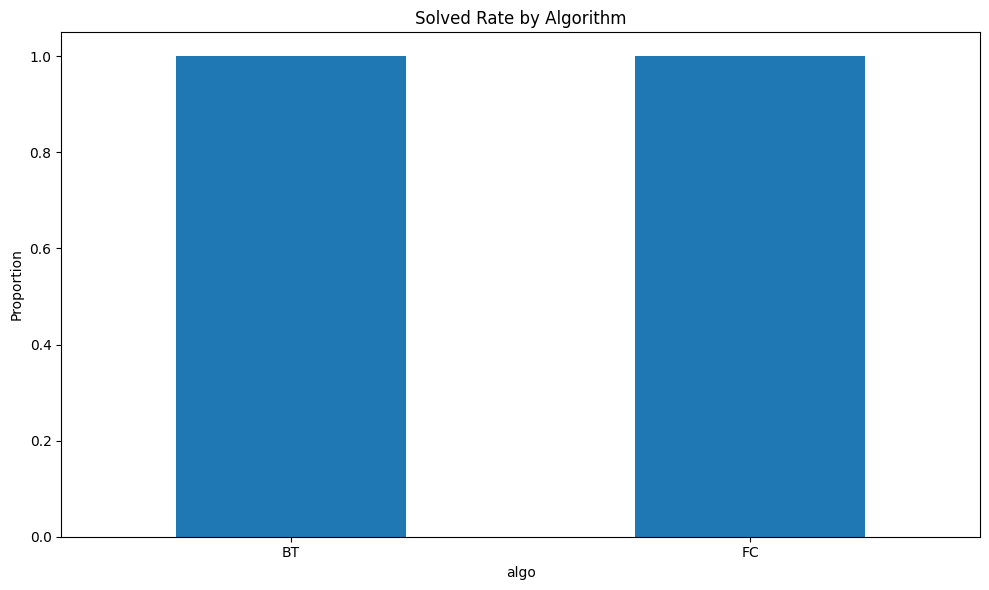

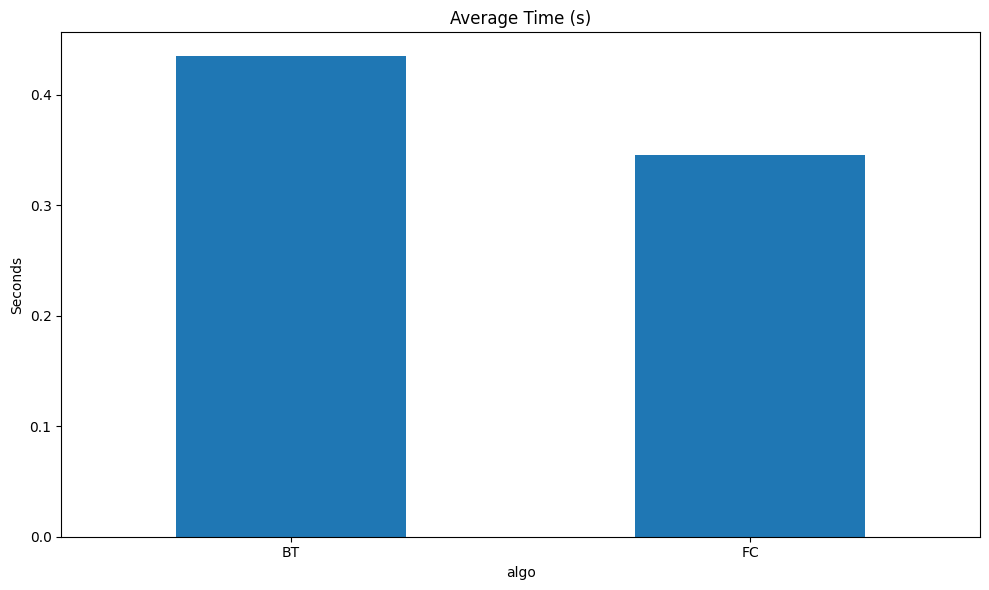

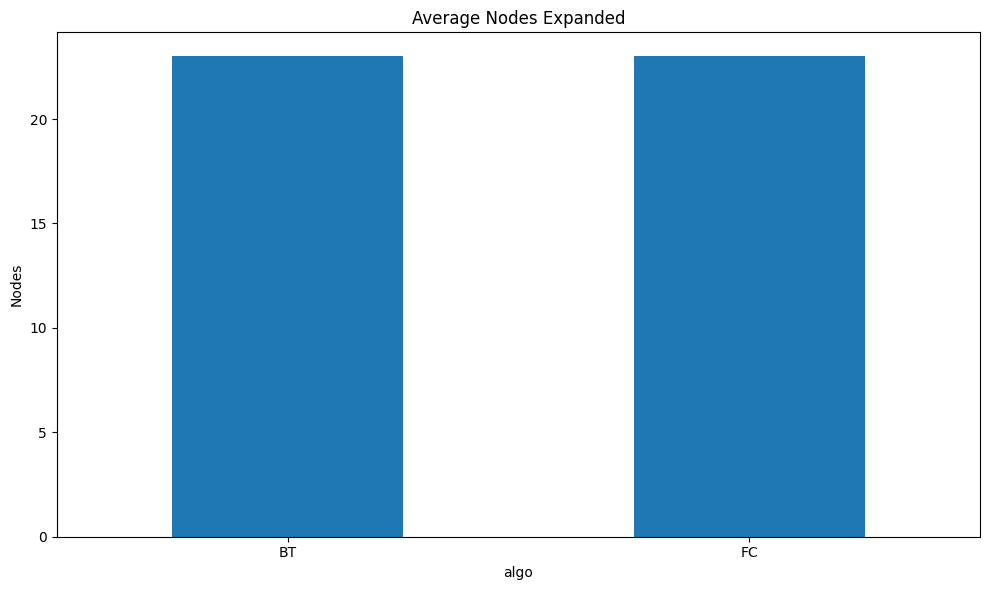

In [43]:
SEED = 11
INSTANCES = 10
N_COURSES = 22
N_TEACHERS = 9
N_GROUPS = 7
N_ROOMS = 6
N_DAYS = 5
SLOTS_PER_DAY = 4
COURSE_SIZE_MIN = 20
COURSE_SIZE_MAX = 70


def run_suite() -> pd.DataFrame:
    rows: List[Dict[str, float]] = []

    for k in range(INSTANCES):
        prob = make_random_problem(
            seed=SEED + k,
            n_courses=N_COURSES,
            n_teachers=N_TEACHERS,
            n_groups=N_GROUPS,
            n_rooms=N_ROOMS,
            n_days=N_DAYS,
            slots_per_day=SLOTS_PER_DAY,
            course_size_range=(COURSE_SIZE_MIN, COURSE_SIZE_MAX),
        )

        csp = TimetableCSP(prob, seed=SEED + k)

        sol_bt, st_bt = csp.solve_backtracking()
        sol_fc, st_fc = csp.solve_forward_checking()

        rows.append({
            "instance": k,
            "algo": "BT",
            **st_bt.as_row(),
            "solved": sol_bt is not None,
        })
        rows.append({
            "instance": k,
            "algo": "FC",
            **st_fc.as_row(),
            "solved": sol_fc is not None,
        })

    return pd.DataFrame(rows)


df = run_suite()
display(df)

summary = (
    df.groupby("algo")
      .agg(
          solved_rate=("solved", "mean"),
          avg_time_s=("time_sec", "mean"),
          median_time_s=("time_sec", "median"),
          avg_nodes=("nodes", "mean"),
          avg_backtracks=("backtracks", "mean"),
      )
      .reset_index()
)
display(summary)

summary.set_index("algo")["solved_rate"].plot(kind="bar", rot=0, title="Solved Rate by Algorithm").set_ylabel("Proportion")
plt.tight_layout()
plt.show()

summary.set_index("algo")["avg_time_s"].plot(kind="bar", rot=0, title="Average Time (s)").set_ylabel("Seconds")
plt.tight_layout()
plt.show()

summary.set_index("algo")["avg_nodes"].plot(kind="bar", rot=0, title="Average Nodes Expanded").set_ylabel("Nodes")
plt.tight_layout()
plt.show()



**Visualization**

In [44]:
prob = make_random_problem(
    seed=SEED,
    n_courses=N_COURSES,
    n_teachers=N_TEACHERS,
    n_groups=N_GROUPS,
    n_rooms=N_ROOMS,
    n_days=N_DAYS,
    slots_per_day=SLOTS_PER_DAY,
    course_size_range=(COURSE_SIZE_MIN, COURSE_SIZE_MAX),
)

csp = TimetableCSP(prob, seed=SEED)
solution, stats = csp.solve_forward_checking()

print(
    f"Solved: {solution is not None} | time: {stats.seconds:.4f}s | "
    f"nodes: {stats.nodes} | backtracks: {stats.backtracks}"
)

if solution:
    display(generate_timetable(prob, solution))
else:
    print("No feasible timetable found.")

Solved: True | time: 0.3426s | nodes: 23 | backtracks: 0


Room 0               Room 1               Room 2  \
Day Slot                                                                  
0   0                                                                     
    1                                                                     
    2     Course 15 | T4 | G3  Course 14 | T3 | G4                        
    3                                                                     
1   0                                                                     
    1                                                                     
    2                                                                     
    3                                               Course 11 | T0 | G1   
2   0                                                                     
    1                                                                     
    2                                                                     
    3     Course 18 | T1 | G5   Course 6 | T8 | G6   Course 1 | T7 | G3   
3   0                                                                     
    1                                                                     
    2                                                                     
    3     Course 19 | T5 | G6                        Course 8 | T7 | G5   
4   0                                                                     
    1      Course 3 | T7 | G5  Course 10 | T8 | G0  Course 12 | T0 | G6   
    2                                                                     
    3                                                                     

                       Room 3               Room 4               Room 5  
Day Slot                                                                 
0   0                                                                    
    1                                               Course 17 | T4 | G3  
    2      Course 0 | T7 | G6                                            
    3                                                                    
1   0                                                                    
    1                          Course 20 | T8 | G2                       
    2                                                                    
    3                                                                    
2   0                                                                    
    1                                                                    
    2                                                                    
    3      Course 4 | T2 | G0   Course 7 | T0 | G4   Course 2 | T3 | G1  
3   0                                                                    
    1                                                                    
    2                                                                    
    3     Course 16 | T1 | G3                        Course 9 | T2 | G4  
4   0                                                                    
    1     Course 13 | T5 | G3  Course 21 | T1 | G4   Course 5 | T4 | G1  
    2                                                                    
    3